<a href="https://www.kaggle.com/code/jamessalcedo/text-sentiment-analysis?scriptVersionId=353344526" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# A. Sentiment Analysis

Use 1k_data_emoji_texts_senti_posneg.xlsx file to find sentiment Analysis using any Machine Learning Algorithm of your choice. This file contains sentiment text as well as UTF-8 code for emojis. Refer the following site to have more ideas about UTF-8. https://www.utf8-chartable.de/unicode-utf8-table.pl?start=127808&utf8=char

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [14]:
import pandas as pd              # To manipulate data using pandas
import matplotlib.pyplot as plt  # To plot graphs

# Used to split the dataset into training and test sets
from sklearn.model_selection import train_test_split

# Used to convert text data into numerical features for modeling
from sklearn.feature_extraction.text import TfidfVectorizer

# For binary classification tasks (predicting positive or negative sentiment)
from sklearn.linear_model import LogisticRegression

# To generate a detailed classification metrics report (precision, recall, F1-score)
from sklearn.metrics import classification_report

In [15]:
# Load datasets
emoji_texts_df = pd.read_csv("/kaggle/input/datasets/jamessalcedo/1k-tweets/1k_data_emoji_tweets_senti_posneg.csv") 
emoticon_reference_df = pd.read_csv("/kaggle/input/datasets/jamessalcedo/emoticon/15_emoticon_data.csv")          

#For testing purposes
print("Sample rows from the dataset:")  # Mag-print ng message para ipakita ang sample data
print(emoji_texts_df.sample(10))      # I-print ang 10 random na rows mula sa dataset

Sample rows from the dataset:
     Unnamed: 0  sentiment                                               post
37           37          1                           New twitter acc. happy 😊
824         824          0  All of the park areas in Paris are marked as g...
31           31          1  yes it would have if it hadn't been for those ...
792         792          1                                               wifi
183         183          0               the email I was hoping I'd get today
690         690          0                            Who hacked me unhappy 😧
220         220          0  Koalas are dying of thirst and it's all becaus...
676         676          0                                       but no sign.
969         969          0                 unhappy 😒 unhappy feeling sick 😧 😧
435         435          0     I miss Jamie boy and we're both sick unhappy 😧


In [16]:
# Function to map emojis to their Unicode names using the reference dataset
emoji_mapping = dict(zip(emoticon_reference_df['Emoji'], emoticon_reference_df['Unicode name']))
# dict - Creates a dictionary (`emoji_mapping`) where each key is an emoji from the reference dataset
# zip - pairs the 'Emoji' and 'Unicode name' columns, converting it to a dictionary

# Replace each emoji in the text with its Unicode name
def replace_emojis_with_names(text):
    for emoji, unicode_name in emoji_mapping.items():
        text = text.replace(emoji, f" {unicode_name} ")
    return text

In [17]:
# Apply the 'replace_emojis_with_names' function to each row of the 'post' column
emoji_texts_df['cleaned_post'] = emoji_texts_df['post'].apply(replace_emojis_with_names)

# The 'apply' function is used to apply the replacement to every text in the 'post' column
# Then, the results are placed in a new column called 'cleaned_post'

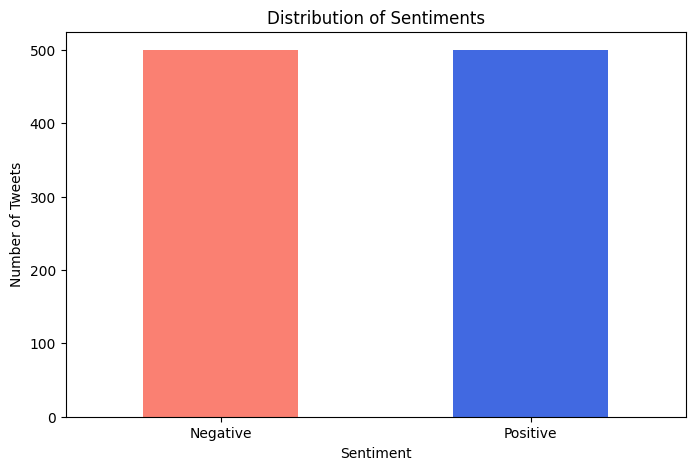

In [18]:
# Create a figure with a size of 8x5 inches
plt.figure(figsize=(8, 5))

# Show the count of each sentiment (Positive and Negative) using a bar chart
# value_counts() - used to count the occurrences of each unique value in the 'sentiment' column
emoji_texts_df['sentiment'].value_counts().plot(kind='bar', color=['Salmon', 'RoyalBlue'])

plt.xlabel("Sentiment")         # X-axis label "Sentiment" - 0 or 1 in the dataset
plt.ylabel("Number of Tweets")  # Y-axis label "Number of Tweets"

plt.title("Distribution of Sentiments")  # Chart title

# Display the x-axis labels "Negative" and "Positive"
plt.xticks(ticks=[0, 1], labels=['Negative', 'Positive'], rotation=0)

# Show the plot
plt.show()

In [19]:
# X is the 'cleaned_post' (posts without emojis, replaced by their Unicode names)
X = emoji_texts_df['cleaned_post']

# y is the 'sentiment' (positive or negative analysis of each post)
y = emoji_texts_df['sentiment']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train_test_split - splits the data into two parts:
   # X_train and y_train - for training (80% of data)
   # X_test and y_test  - for testing (20% of data, because test_size=0.2)

# random_state=42 ensures the data split is identical every time the code runs

In [20]:
vectorizer = TfidfVectorizer(max_features=10000) 
# Transforms texts (tweets) into numbers using TF-IDF.
# 'max_features=10000' means it will only select the top 10,000 most important words.

X_train_tfidf = vectorizer.fit_transform(X_train) 
# Convert the training data ('X_train') into numbers using TF-IDF.

X_test_tfidf = vectorizer.transform(X_test)
# Do the same for the test data ('X_test'), converting it to numbers.

# Create a Logistic Regression model
model = LogisticRegression(random_state=42)
# Logistic Regression is chosen because it fits well for this classification, especially with 0 and 1 data.
# 'random_state=42' for consistent results every time it runs.

model.fit(X_train_tfidf, y_train)
# Train the model using the training data ('X_train_tfidf') and the correct labels ('y_train') 

# Make predictions using the test data
y_pred = model.predict(X_test_tfidf) 
# Now, using what the model learned, predict if the sentiment of the test data is positive or negative.

# Show the model performance report
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))
# The report shows how well the model predicts positive or negative sentiments.

              precision    recall  f1-score   support

    Negative       0.80      0.75      0.77        91
    Positive       0.80      0.84      0.82       109

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200



# B. Further, you can build a real-time text sentiment Analyzer.

Some ideas for this part: First make a definition with a simple sentence as a parameter: '😍 I love sentiment analysis 😊'. Now this sentence will use the classifier you have developed in Question-A, to identify the polarity. 

Further, develop a text box to take real time texts, I,e sentences with emojis provided by user using key board to analyze the sentiments of the given sentences.

Note: Do not use Vader sentiment Analysis

Hint: Use ipywidgets library to add textbox and buttons. The final output is something like the one as follows:

No matter, if you are using a different design as long as your text box takes texts from user and show the polarity of the sentence, in real time.

In [21]:
import ipywidgets as widgets         # Library to create widgets
from IPython.display import display  # Used to display widgets in Jupyter

def sentiment_analyzer_widget():
    # Create a text box widget for user input
    text_box = widgets.Text(
        description="INPUT TEXT:", 
        placeholder="Enter text here..."
    )
    # Create a label widget to display the output (sentiment prediction)
    output_label = widgets.Label()

    # Display the text box and output label
    display(text_box, output_label)
   
    def predict_sentiment(text):
        cleaned_text = replace_emojis_with_names(text)        # Replace emojis with their names
        tfidf_features = vectorizer.transform([cleaned_text]) # Convert text into numerical features
        sentiment_label = model.predict(tfidf_features)[0]    # Use the model to predict sentiment
        return "👍POSITIVE👍" if sentiment_label == 1 else "👎NEGATIVE👎" # Map result to positive or negative
    
    # Function to handle changes in user text input
    def analyze_sentiment(change):
        text = text_box.value
        if text.strip():                                      # If there is text input
            sentiment = predict_sentiment(text)               # Predict the sentiment
            output_label.value = f"Real-Time Prediction: '{sentiment}' SENTIMENT" # Display the prediction
        else:
            output_label.value = "Please enter a text."      # If there is no text, this is the default
    
    # Add an event handler to the text box (triggers when the value changes)
    text_box.observe(analyze_sentiment, names='value')

# Run the widget
sentiment_analyzer_widget()

Text(value='', description='INPUT TEXT:', placeholder='Enter text here...')

Label(value='')